# Đánh giá độ bền trước nhiễu Gauss (Gaussian Noise Robustness Benchmark)

Thực nghiệm kiểm chứng **Mệnh đề 3** trong `docs/THEORY_NOTES.md`:
So sánh độ bền của 3 bộ ước lượng:
- **KSG (k-NN phi tham số)**
- **Amortized MINE (Tham số học sẵn)**
- **Hybrid (Lai ghép KSG cho N<50 và Amortized cho N>=50)**

Dưới các mức nhiễu trắng Gauss cộng tính (AWGN): Clean (inf dB) -> 20dB -> 15dB -> 10dB -> 5dB -> 0dB.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập JAVA_HOME cho JPype/IDTxl
if 'JAVA_HOME' not in os.environ:
    os.environ['JAVA_HOME'] = r'C:\Users\Nguyen Dao Nam Hai\.jdks\ms-17.0.17'

# Tự động tìm project root dù chạy từ thư mục nào
curr = Path.cwd()
root = curr if (curr / 'src').exists() else (curr.parent if (curr.parent / 'src').exists() else Path(r'D:\SPARC Lab\PQRST'))
os.chdir(root)
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from pqrst.evaluation.noise_benchmark import run_noise_benchmark, summarize_noise_benchmark, plot_noise_robustness

In [2]:
checkpoint_path = 'results/checkpoints/phi_amortized_standardized.pt'
n_windows_per_cell = 30  # Số cửa sổ mỗi ô lưới
snr_levels = [None, 20.0, 15.0, 10.0, 5.0, 0.0]
n_samples_list = [20, 50, 100]

print(f'Bắt đầu benchmark với {n_windows_per_cell} cửa sổ mỗi ô lưới...')
raw_df = run_noise_benchmark(
    checkpoint_path=checkpoint_path,
    n_windows_per_cell=n_windows_per_cell,
    snr_levels=snr_levels,
    n_samples_list=n_samples_list
)
summary_df = summarize_noise_benchmark(raw_df)
summary_df.to_csv('results/tables/noise_robustness_benchmark.csv', index=False)
display(summary_df.head(15))

Bắt đầu benchmark với 30 cửa sổ mỗi ô lưới...


,snr_db,snr_label,n_samples,estimator,n_valid,mean_estimate,bias,variance,mse
0,0.0,0dB,20,Amortized,30,0.048117,-0.133278,0.008876,0.026343
1,0.0,0dB,20,Hybrid,30,0.021434,-0.159961,0.004289,0.029734
2,0.0,0dB,20,KSG,30,0.021434,-0.159961,0.004289,0.029734
3,0.0,0dB,50,Amortized,30,0.014073,-0.167322,0.003016,0.030912
4,0.0,0dB,50,Hybrid,30,0.014073,-0.167322,0.003016,0.030912
5,0.0,0dB,50,KSG,30,0.010010,-0.171385,0.002512,0.031801
6,0.0,0dB,100,Amortized,30,0.031505,-0.149890,0.001611,0.024024
7,0.0,0dB,100,Hybrid,30,0.031505,-0.149890,0.001611,0.024024
8,0.0,0dB,100,KSG,30,0.036272,-0.145122,0.001536,0.022545
9,5.0,5dB,20,Amortized,30,0.076493,-0.104902,0.006900,0.017675


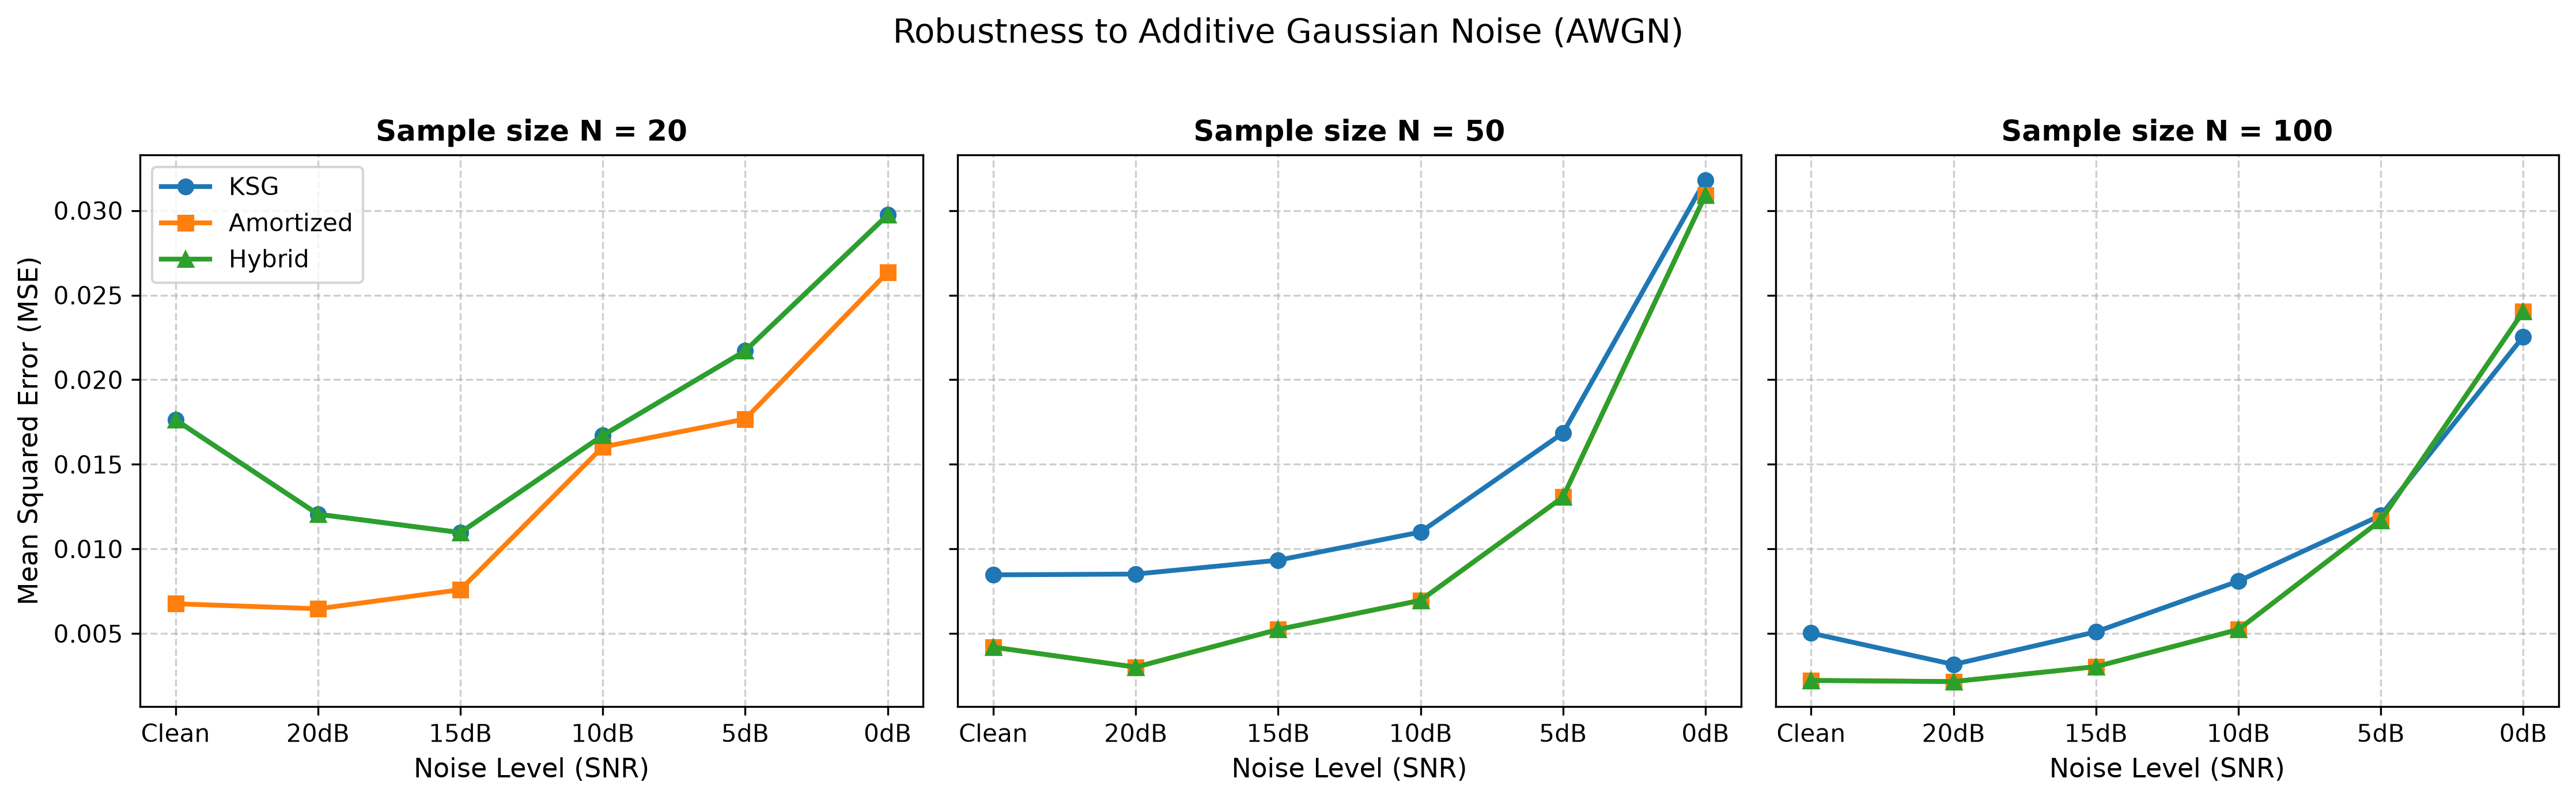

In [3]:
plot_noise_robustness(summary_df, 'results/figures/noise_robustness_mse.png')
from IPython.display import Image
Image('results/figures/noise_robustness_mse.png')